**BANK CUSTOMER CHURN PREDICTION**
###### - ANANYA PATANKAR


---


For predicting bank churn, the following models are selected -

1)Logistic Regression

2)Random Forest Classifier

3)XGBoost Classifier

4)LightGBM Classifier

These models are considered best for binary classification problems since they are capable of identifying patterns and relationships from the data and then classifying customers into two categories- churned (1) and not churned (0).

In [1]:
#import required libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import(accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)
import joblib

In [2]:
#load processed datasets
X_train = pd.read_csv('X_train_final.csv')
X_test = pd.read_csv('X_test_final.csv')
y_train = pd.read_csv('y_train_final.csv').squeeze()
y_test = pd.read_csv('y_test_final.csv').squeeze()

**MODEL BUILDING :**

In [3]:
#instantiate all models
log_reg = LogisticRegression(random_state=42, max_iter= 1000)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100)

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

lgbm_model = LGBMClassifier(random_state=42, verbose=-1)

#store them in a dictionary
models = {'Logistic Regression':log_reg, 'Random Forest':rf_model, 'XGBoost':xgb_model, 'LightGBM':lgbm_model}

**MODEL TRAINING AND EVALUATION :**

In [4]:
#train models and calculate metrics
results=[]

for name,model in models.items():
  model.fit(X_train, y_train)
  y_pred=model.predict(X_test)
  y_pred_proba = model.predict_proba(X_test)[:,1]

  results.append({'Model':name,'Accuracy':accuracy_score(y_test, y_pred),
                'Precision':precision_score(y_test, y_pred),
                'Recall'   : recall_score(y_test, y_pred),
                'F1 Score' : f1_score(y_test, y_pred),
                'ROC-AUC'  : roc_auc_score(y_test, y_pred_proba)})

**COMPARING MODELS :**

In [5]:
results_df = pd.DataFrame(results)

#sort by ROC-AUC
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

#convert to percentages
results_df_display = results_df.copy()
for col in ['Accuracy','Precision','Recall','F1 Score','ROC-AUC']:
    results_df_display[col] = results_df_display[col].map('{:.2%}'.format)

display(results_df_display)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,LightGBM,86.10%,69.25%,57.00%,62.53%,85.88%
1,Random Forest,84.35%,62.84%,56.51%,59.51%,84.71%
2,Logistic Regression,78.10%,47.50%,72.24%,57.31%,84.03%
3,XGBoost,85.10%,66.47%,54.05%,59.62%,83.68%


ROC-AUC is considered the primary metric for bank churn prediction, hence the results are sorted according to it. Unlike accuracy, it measures how well the model separates churners from non-churners across all possible probability thresholds, not just at the default 0.5 cutoff. This makes it a more reliable metric to evaluate the performance of models.

LightGBM has the highest ROC-AUC (85.88%), accuracy (86.10%), F1 score (62.53%), and second-highest recall (57%), making it the best overall model for predicting bank churn.

Random Forest is the second best, with ROC-AUC of 84.71% and performing consistently across all metrics.

Logistic Regression, the baseline method, has a ROC-AUC of 84.03% with the highest Recall (72.24%). However its low precision (47.50%) shows that more than half of its churn predictions are false alarms.

XGBoost underperforms, having the lowest ROC-AUC (83.68%) and lowest Recall (54.05%).

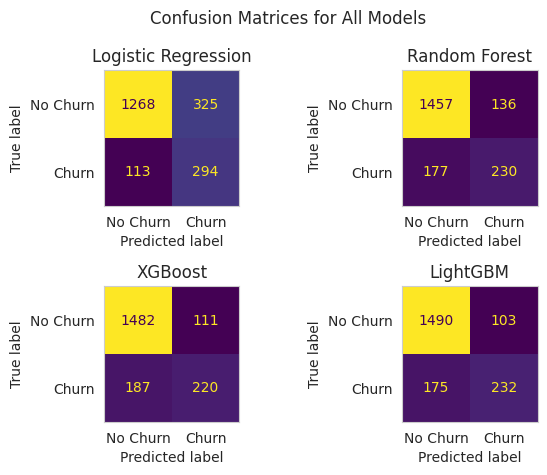

In [6]:
#plot confusion matrices for each model
fig,axes = plt.subplots(2,2)
axes = axes.flatten()

for idx, (name,model) in enumerate(models.items()):
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn','Churn'])
  disp.plot(ax=axes[idx], colorbar=False)
  axes[idx].grid(False)
  axes[idx].set_title(name)

plt.suptitle('Confusion Matrices for All Models')
plt.tight_layout()
plt.show()

False negatives are a costly error for predicting churn, since actual churners are missed by the model, giving the bank no chances to retain them. Hence a reliable model must have lower rate of false negatives (here, bottom left box in the matrix).

Logistic Regression has the lowest false negatives (113) but gives highest number of false positives (325).

Random Forest gives moderate false negatives (177) and false positives (136).

XGBoost performs the worst by having highest false negatives (187), though gives less false alarms (111).

The best model here is LightGBM. It correctly predicts 1490 true negatives (highest) and 232 true positives (second highest). It misses 175 churners (second best) while giving the lowest false positives.

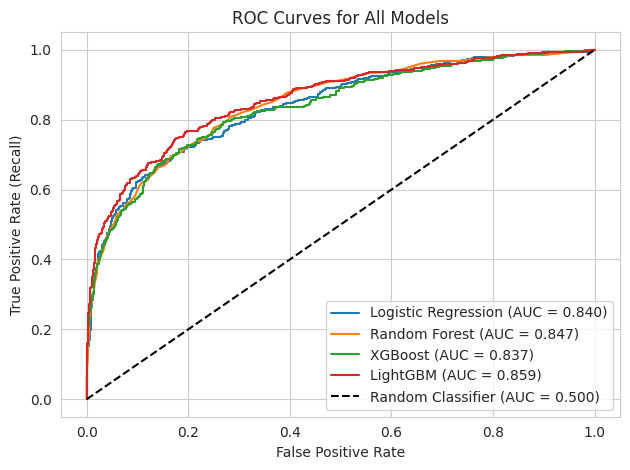

In [7]:
#plot ROC curves for each model
for name, model in models.items():
  y_pred_proba = model.predict_proba(X_test)[:,1]
  fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
  auc = roc_auc_score(y_test, y_pred_proba)
  plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0,1],[0,1], 'k--', label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

All models perform similarly as seen by the curves clustered closely. This suggests that the feature engineering and preprocessing steps have helped the algorithms learn meaningful patterns from the data.

LightGBM (AUC = 0.859) performs better other models, especially in the low False Positive Rate region (0.0 to 0.2) which is the most important zone. In this region,the model identifies the most churners while minimising false
alarms, which is the bank's focus for during retention campaigns. This confirms that LightGBM as the best model for customer churn prediction.

**SELECTING BEST MODEL :**

In [8]:
#select best model based on ROC-AUC
best_model_name= results_df.iloc[0]['Model']
best_model= models[best_model_name]
best_auc= results_df.iloc[0]['ROC-AUC']

print(f"Best Model:{best_model_name}")
print(f"ROC-AUC Score: {best_auc:.4f}")

Best Model:LightGBM
ROC-AUC Score: 0.8588


**SAVING TRAINED MODELS :**

In [9]:
#save all trained models
for name, model in models.items():
  filename = name.lower().replace(' ', '_') + '.pkl'
  joblib.dump(model, filename)

LightGBM is carried forward as the best model for hyperparameter tuning in the next stage.